# 04 · Yield-stress fluids

Drilling muds carry rock cuttings out of a well and must hold them in suspension when circulation stops.
Chocolate must coat a biscuit without running off. Fresh concrete must stand in a pile yet flow when pumped.
All of them are **yield-stress fluids**: below a critical stress they behave like soft solids, above it they
flow. This notebook fits yield-stress models to three industrial data sets and shows why "the" yield
stress is a slippery quantity.

**What you will learn**
- fit Bingham, Herschel-Bulkley and Casson models
- compare API field formulas with proper fits
- explain why a yield stress depends on the model and the measuring range
- relate yield-stress parameters to industrial requirements

**Before you start:** notebooks 02-03  ·  **Time:** about 60-75 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engrheo import datasets, fitting, geometry, models
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## A drilling mud: field formulas against proper fits
Drilling-fluid laboratories record six dial readings of a Fann 35 viscometer and use simple API formulas:
plastic viscosity PV = $\theta_{600} - \theta_{300}$ and yield point YP = $\theta_{300}$ - PV (the Bingham line through the two
highest readings).

In [2]:
mud = pd.read_csv(datasets.path("drilling_mud_fann.csv"), comment="#")
print(mud.to_string(index=False))
th = dict(zip(mud.rpm, mud.dial_reading_deg))
api = geometry.api_bingham(th[600], th[300])
print(f"\nAPI: PV = {api['PV_mPas']:.1f} mPa s, YP = {api['YP_lbf100ft2']:.1f} lbf/100 ft2 = {api['tau_y']:.2f} Pa")
tau_m, rate_m = geometry.fann35(mud.rpm.to_numpy(), mud.dial_reading_deg.to_numpy())
order = np.argsort(rate_m)
rate_m, tau_m = rate_m[order], tau_m[order]
for name in ("bingham", "herschel_bulkley", "power_law"):
    f = fitting.fit_flow_curve(rate_m, tau_m, name)
    print(f"{name:<17}: " + ", ".join(f"{k} = {v:.3g}" for k, v in f.params.items()) + f"   (scatter {100*f.sigma:.1f} %)")
print("true fluid (used to generate the readings): Herschel-Bulkley tau_y = 4.8 Pa, K = 0.35 Pa s^n, n = 0.62")

 rpm  dial_reading_deg
 600              61.5
 300              43.5
 200              36.0
 100              27.0
   6              13.0
   3              12.0

API: PV = 18.0 mPa s, YP = 25.5 lbf/100 ft2 = 12.21 Pa
bingham          : tau_y = 6.52, mu_p = 0.0301   (scatter 13.7 %)
herschel_bulkley : tau_y = 5.15, K = 0.355, n = 0.621   (scatter 0.2 %)
power_law        : K = 3.44, n = 0.298   (scatter 11.8 %)
true fluid (used to generate the readings): Herschel-Bulkley tau_y = 4.8 Pa, K = 0.35 Pa s^n, n = 0.62


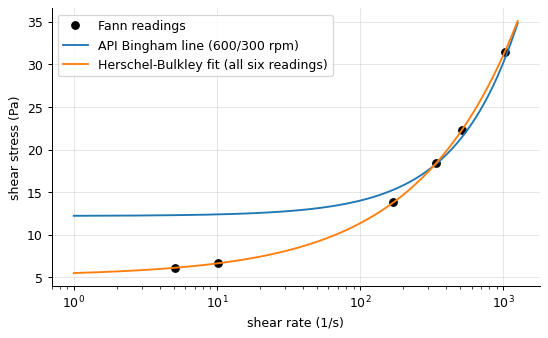

In [3]:
rr = np.logspace(0, 3.1, 200)
hb = fitting.fit_flow_curve(rate_m, tau_m, "herschel_bulkley")
plt.plot(rate_m, tau_m, "ko", label="Fann readings")
plt.plot(rr, models.stress("bingham", rr, api["tau_y"], api["mu_p"]), label="API Bingham line (600/300 rpm)")
plt.plot(rr, hb.predict_stress(rr), label="Herschel-Bulkley fit (all six readings)")
plt.xscale("log"); plt.xlabel("shear rate (1/s)"); plt.ylabel("shear stress (Pa)"); plt.legend(); plt.show()

The API yield point is the intercept of a straight line through the two *highest* readings - an
extrapolation over two decades of shear rate to zero. For a shear-thinning mud it overestimates the stress
at low rates, which is exactly where cuttings are suspended. The Herschel-Bulkley fit uses all six readings
and lands much closer to the true yield stress. (The low-speed readings have their own problem: at 3 and
6 rpm only part of the gap is sheared - notebook 02 - so their Newtonian rate conversion is approximate.)

## Chocolate: the yield stress depends on the model
The confectionery industry has long described molten chocolate with the Casson model.

In [4]:
choc = pd.read_csv(datasets.path("chocolate_casson.csv"), comment="#")
rc, tc = choc.shear_rate_1_s.to_numpy(), choc.shear_stress_Pa.to_numpy()
fits, text = fitting.compare_models(rc, tc, ("casson", "bingham", "herschel_bulkley"))
print(text)
for f in fits:
    print(f"{f.model:<17}: yield stress {f.params['tau_y']:6.2f} Pa")
print("true fluid: Casson tau_y = 12 Pa, eta_c = 2.1 Pa s")

           model  parameters  scatter %     AIC  delta AIC  yield stress
------------------------------------------------------------------------
          casson           2      1.391  -83.73          0           yes
herschel_bulkley           3      1.795  -77.97      5.756           yes
         bingham           2      5.465  -56.37      27.36           yes
casson           : yield stress  12.25 Pa
herschel_bulkley : yield stress  17.74 Pa
bingham          : yield stress  26.03 Pa
true fluid: Casson tau_y = 12 Pa, eta_c = 2.1 Pa s


Casson and Herschel-Bulkley both fit the measured range (2-50 1/s) within the noise; Bingham fits
noticeably worse. Yet even the two good models disagree about the yield stress by almost half, and the
three together span a factor of two. None of these values is *measured*: each is an extrapolation of a
model to zero shear rate, below the lowest data point. A yield
stress is only meaningful together with the model and the shear-rate range used - which is why standards
(for chocolate, the ICA method) fix both. Direct methods - stress ramps, creep tests, oscillatory amplitude
sweeps (notebook 08) - measure the onset of flow instead of extrapolating.

## Fresh concrete

In [5]:
conc = pd.read_csv(datasets.path("concrete_flow_curve.csv"), comment="#")
bing = fitting.fit_flow_curve(conc.shear_rate_1_s, conc.shear_stress_Pa, "bingham")
print(bing)
print("true fluid: Bingham tau_y = 600 Pa, plastic viscosity 45 Pa s")

bingham fit to 8 points: relative scatter 3.89 %, AIC -50.25
parameter   value  std. error  95% low  95% high
------------------------------------------------
    tau_y  623.88      17.462   581.15    666.61
     mu_p  43.102      2.4929   37.002    49.202
true fluid: Bingham tau_y = 600 Pa, plastic viscosity 45 Pa s


For concrete the Bingham model is the standard, and its two parameters map onto the two things site
engineers care about: the yield stress governs whether concrete holds its shape (slump), the plastic
viscosity how hard it is to pump (notebook 15).

## Inside the algorithm: the classic Casson straight line
Casson plotted $\sqrt\tau$ against $\sqrt{\dot\gamma}$: a straight line with intercept $\sqrt{\tau_y}$ and slope $\sqrt{\eta_c}$.
Ordinary regression on that plot weights the points differently from the library's log-residual fit:

In [6]:
slope, intercept = np.polyfit(np.sqrt(rc), np.sqrt(tc), 1)
print(f"Casson straight line: tau_y = {intercept**2:.3f} Pa, eta_c = {slope**2:.3f} Pa s")
cf = fitting.fit_flow_curve(rc, tc, "casson")
print(f"log-residual fit:     tau_y = {cf.params['tau_y']:.3f} Pa, eta_c = {cf.params['eta_c']:.3f} Pa s")

Casson straight line: tau_y = 12.164 Pa, eta_c = 2.070 Pa s
log-residual fit:     tau_y = 12.252 Pa, eta_c = 2.059 Pa s


## Exercises
1. Drilling engineers estimate the true yield stress with the low-shear yield point LSYP = $2\theta_3 - \theta_6$ (lbf/100 ft², × 0.4788 for Pa). Compute it for the mud and compare with the API yield point, the Herschel-Bulkley $\tau_y$ and the true value (4.8 Pa).
2. Fit the Herschel-Bulkley model to the chocolate data using only the rates above 10 1/s. How much does the yield stress change? What does that say about extrapolated yield stresses?
3. **Implement it yourself:** fit the Bingham model to the concrete data by an ordinary straight-line fit of stress against rate (`np.polyfit`) and compare with the library's log-residual fit. Which points does each weight most?